## Tensor Networks Fopra  Day 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from a_mps import *
from b_model import *
from c_tebd import *

In [4]:
"Part 4.1a"

L = 14
mp = init_spinup_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))


sigma_x expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
"Part 4.1b"

def init_plus_MPS(L):
    """Return a product state with all spins right as an MPS"""
    B = np.zeros([1, 2, 1], float)
    B[0, 0, 0] = 1/np.sqrt(2)
    B[0, 1, 0] = 1/np.sqrt(2)
    S = np.ones([1], float)
    Bs = [B.copy() for i in range(L)]
    Ss = [S.copy() for i in range(L)]
    return MPS(Bs, Ss)

L = 14
mp = init_plus_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))

sigma_x expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
"Part 4.1b"

def init_plus_MPS(L):
    """Return a product state with all spins right as an MPS"""
    B = np.zeros([1, 2, 1], float)
    B[0, 0, 0] = 1/np.sqrt(2)
    B[0, 1, 0] = 1/np.sqrt(2)
    S = np.ones([1], float)
    Bs = [B.copy() for i in range(L)]
    Ss = [S.copy() for i in range(L)]
    return MPS(Bs, Ss)

L = 14
mp = init_plus_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))

sigma_x expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


For g =  0.5  and for the spin-up state E =  -7.0
For g =  0.5  and for the plus state E =  -12.999999999999996
For g =  1  and for the spin-up state E =  -14.0
For g =  1  and for the plus state E =  -12.999999999999996
For g =  1.5  and for the spin-up state E =  -21.0
For g =  1.5  and for the plus state E =  -12.999999999999996
finite TEBD, (imaginary time evolution)
L=14, J=1.0, g=0.50
dt = 0.10000: E = -14.0169651750681
dt = 0.01000: E = -14.0188031390760
dt = 0.00100: E = -14.0189769069207
dt = 0.00010: E = -14.0189942268148
dt = 0.00001: E = -14.0189959585365
final bond dimensions:  [2, 4, 8, 14, 18, 20, 20, 20, 18, 14, 8, 4, 2]
finite TEBD, (imaginary time evolution)
L=14, J=1.0, g=1.00
dt = 0.10000: E = -17.4149126671984
dt = 0.01000: E = -17.4657339106461
dt = 0.00100: E = -17.4704766397477
dt = 0.00010: E = -17.4709480543445
dt = 0.00001: E = -17.4709952214514
final bond dimensions:  [2, 4, 8, 16, 21, 24, 24, 24, 21, 16, 8, 4, 2]
finite TEBD, (imaginary time evolution)
L=14

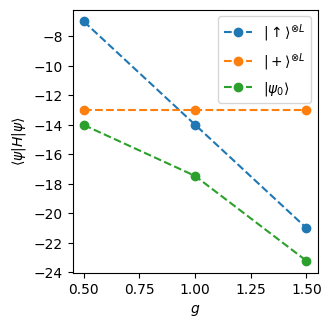

In [26]:
"Part 4.1c"

onecolumnfigsize = (3.375, 3.375 / 1.618)
onecolumnfigsizetall = (3.375, 3.375)


L = 14
J = 1
gs = [0.5, 1, 1.5]
mp_spinup = init_spinup_MPS(L)
mp_plus = init_plus_MPS(L)
energies_spinup = {}
energies_plus = {}
import matplotlib.pyplot as plt

for g in gs:
  tfi = TFIModel(L, J, g)
  energies_spinup[g] = tfi.energy(mp_spinup)
  energies_plus[g] = tfi.energy(mp_plus)

  print("For g = ", g, " and for the spin-up state E = ", tfi.energy(mp_spinup))
  print("For g = ", g, " and for the plus state E = ", tfi.energy(mp_plus))

"Part 4.1d"

ground_state_energy = [example_TEBD_gs_finite(L=L, J=1., g=g)[0] for g in gs]

plt.figure(figsize=onecolumnfigsizetall)
plt.plot(gs, energies_spinup.values(), ls="--", marker="o",label=r'$| \uparrow \rangle^{\otimes L}$')
plt.plot(gs, energies_plus.values(), ls="--", marker="o", label=r'$| + \rangle^{\otimes L}$')
plt.plot(gs, ground_state_energy, ls="--", marker="o", label=r'$| \psi_0 \rangle$')
plt.plot()
plt.xlabel(r'$g$')
plt.ylabel(r'$\langle \psi | H | \psi \rangle$')
plt.legend()
plt.tight_layout()
plt.savefig("plots/energy_comparison.pdf")
plt.show()

In [7]:
# Also adding longitudinal field
class TLFIModel(TFIModel):
    """Class generating the Hamiltonian of the transverse-field Ising model.

    The Hamiltonian reads
    .. math ::
        H = - J \\sum_{i} \\sigma^x_i \\sigma^x_{i+1} - g \\sum_{i} \\sigma^z_i

    Parameters
    ----------
    L : int
        Number of sites.
    J, g : float
        Coupling parameters of the above defined Hamiltonian.

    Attributes
    ----------
    L : int
        Number of sites.
    d : int
        Local dimension (=2 for spin-1/2 of the transverse field ising model)
    sigmax, sigmay, sigmaz, id :
        Local operators, namely the Pauli matrices and identity.
    H_bonds : list of np.Array[ndim=4]
        The Hamiltonian written in terms of local 2-site operators, ``H = sum_i H_bonds[i]``.
        Each ``H_bonds[i]`` has (physical) legs (i out, (i+1) out, i in, (i+1) in),
        in short ``i j i* j*``.
    """

    def __init__(self, L, J, g, h):
        self.L, self.d = L, 2
        self.J, self.g, self.h = J, g, h
        self.sigmax = np.array([[0., 1.], [1., 0.]])
        self.sigmay = np.array([[0., -1j], [1j, 0.]])
        self.sigmaz = np.array([[1., 0.], [0., -1.]])
        self.id = np.eye(2)
        self.init_H_bonds()

    def init_H_bonds(self):
        """Initialize `H_bonds` hamiltonian. Called by __init__()."""
        sx, sz, id = self.sigmax, self.sigmaz, self.id
        d = self.d
        H_list = []
        for i in range(self.L - 1):
            gL = gR = 0.5 * self.g
            hL = hR = 0.5 * self.h
            if i == 0: # first bond
                gL = self.g
                hL = self.h
            if i + 1 == self.L - 1: # last bond
                gR = self.g
                hR = self.h
            H_bond = -self.J * np.kron(sx, sx) - gL * np.kron(sz, id) - gR * np.kron(id, sz) - hL * np.kron(sx, id) - hR * np.kron(id, sx)
            # H_bond has legs ``i, j, i*, j*``
            H_list.append(np.reshape(H_bond, [d, d, d, d]))
        self.H_bonds = H_list

    def energy(self, psi):
        """Evaluate energy E = <psi|H|psi> for the given MPS."""
        assert psi.L == self.L
        return np.sum(psi.bond_expectation_value(self.H_bonds))

In [8]:
"Part 4.2a"

def correlation(psi: MPS, X, Y, i):
  correlations = []
  theta_i = psi.get_theta1(i)
  contr = np.array(X)@np.array(Y) # pU, pD
  contr = np.tensordot(theta_i, contr, axes =[[1], [0]]) #vL, vR, pD
  contr = np.tensordot(contr, np.conj(theta_i), axes=[[0, 2, 1],[0, 1, 2]])
  correlations.append(contr.item())

  environment = np.tensordot(theta_i, X, axes=[[1],[0]]) #vL, vR, pD
  environment = np.tensordot(environment, np.conj(theta_i), axes=[[0, 2],[0, 1]]) #vR1, vR2
  for j in range(i+1, psi.L):
    beta_current = psi.Bs[j]
    environment = np.tensordot(environment, beta_current, axes=[[0],[0]]) # vR2, pD, vR1
    environment = np.tensordot(environment, np.conj(beta_current), axes = [[0],[0]]) # pD, vR1, pU, vR2
    temp = np.tensordot(environment, Y, axes = [[0, 2], [0, 1]]) # vR1, vR2
    trace = np.trace(temp, axis1=0, axis2=1)
    correlations.append(np.real_if_close(trace))
    environment = np.trace(environment, axis1=0, axis2=2)

  return correlations


In [26]:
"Part 4.2b"

L=30
J=1

def example_TEBD_gs_finite(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    #import a_mps
    #import b_model
    model = TFIModel(L, J=J, g=g)
    psi = init_spinup_MPS(L)
    for dt in [0.1, 0.01, 0.001, 1.e-4, 1.e-5]:
        U_bonds = calc_U_bonds(model, dt)
        run_TEBD(psi, U_bonds, N_steps=500, chi_max=100, eps=1.e-10)
        E = model.energy(psi)
        print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))
    print("final bond dimensions: ", psi.get_chi())
    return E, psi, model

def TEBD_gs_finite_correlations(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    model = TFIModel(L=L, J=J, g=g)
    psi = init_spinup_MPS(L)
    dt = 1.e-5
    U_bonds = calc_U_bonds(model, dt)
    run_TEBD(psi, U_bonds, N_steps=1000, chi_max=100, eps=1.e-10)
    E = model.energy(psi)
    print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))


    return E, psi, model

gs = [0.3, 0.5, 0.8, 0.9, 1., 1.1, 1.2, 1.5]
energies = []
correlations = {}
x_axis = np.arange(L//4, L)
for g in gs:
  E, psi, model = example_TEBD_gs_finite(L=L, J=J, g=g)
  energies.append(E)
  correlations[g] = correlation(psi, sigma_x, sigma_x, L//4)

finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.30
dt = 0.10000: E = -29.7237778057965
dt = 0.01000: E = -29.7243442589172
dt = 0.00100: E = -29.7244030096187
dt = 0.00010: E = -29.7244089062471
dt = 0.00001: E = -29.7244094959373
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.50
dt = 0.10000: E = -31.0307109228222
dt = 0.01000: E = -31.0351587180616
dt = 0.00100: E = -31.0356104605838
dt = 0.00010: E = -31.0356557268945
dt = 0.00001: E = -31.0356602537848
final bond dimensions:  [2, 4, 8, 14, 18, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 18, 14, 8, 4, 2]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.80
dt = 0.10000: E = -34.3536078657672
dt = 0.01000: E = -34.3864798964379
dt = 0.00100: E = -34.3896367076687
dt = 0.00010: E = -34.3899515282532
dt = 0.00001: E = -34.3899830153061
final bond

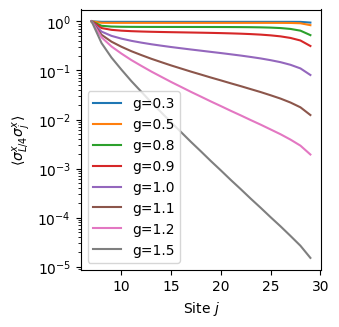

In [31]:
plt.figure(figsize=onecolumnfigsizetall)
for g in gs:
    plt.plot(x_axis, (correlations[g]), label=f"g={g}")

plt.xlabel(r"Site $j$")
plt.ylabel(r'$\langle \sigma^x_{L/4} \sigma^x_{j} \rangle$')
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.savefig("plots/correlations.pdf")
plt.show()


In [29]:
L=30
J=1

def example_TEBD_gs_finite(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    #import a_mps
    #import b_model
    model = TFIModel(L, J=J, g=g)
    psi = init_spinup_MPS(L)
    for dt in [0.1, 0.01]:
        U_bonds = calc_U_bonds(model, dt)
        run_TEBD(psi, U_bonds, N_steps=500, chi_max=100, eps=1.e-10)
        E = model.energy(psi)
        print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))
    print("final bond dimensions: ", psi.get_chi())
    return E, psi, model


gs = [0.3, 0.5, 0.8, 0.9, 1., 1.1, 1.2, 1.5]
energies = []
correlations = {}
x_axis = np.arange(L//4, L)
magnetisation = []
for g in gs:
  E, psi, model = example_TEBD_gs_finite(L=L, J=J, g=g)
  energies.append(E)
  correlations[g] = correlation(psi, sigma_x, sigma_x, L//4)
  magnetisation.append(np.sqrt(correlations[g][5*L//8]))
  print(magnetisation)

finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.30
dt = 0.10000: E = -29.7237778057965
dt = 0.01000: E = -29.7243442589172
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
[np.float64(0.9882786163051127)]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.50
dt = 0.10000: E = -31.0307109228222
dt = 0.01000: E = -31.0351587180616
final bond dimensions:  [2, 4, 8, 14, 18, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 18, 14, 8, 4, 2]
[np.float64(0.9882786163051127), np.float64(0.9645728715632862)]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.80
dt = 0.10000: E = -34.3536078657672
dt = 0.01000: E = -34.3864798964379
final bond dimensions:  [2, 4, 8, 16, 22, 28, 32, 34, 34, 36, 36, 36, 38, 40, 40, 40, 38, 36, 36, 36, 34, 34, 32, 28, 22, 16, 8, 4, 2]
[np.float64(0.9882786163051127), np.float64(0.9645728715632862), np.float64(0.8631247522085992)]
fini

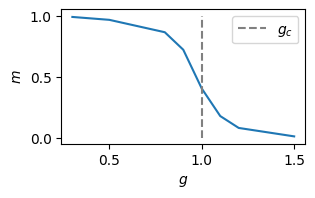

In [37]:
"4.2c"

plt.figure(figsize=onecolumnfigsize)
plt.plot(gs, magnetisation)
plt.ylabel(r'$m$')
plt.xlabel(r'$g$')
plt.vlines(1, ls="--", color="gray", label=r"$g_c$", ymin=0, ymax=1)
plt.legend()
plt.tight_layout()
plt.savefig("plots/magnetisation.pdf")
plt.show()


## Day 2

**To Do**
- we are still missing plots of entropy 
- we have to adjust parameters, s.t. light cone doesnt get reflected from boundary

In [10]:
"Day 2 Part 4.2"

from a_mps import *
from b_model import *
from c_tebd import *

def apply_operator(psi, op, j):
  psi.Bs[j] = np.tensordot(psi.Bs[j], op, axes = [[1],[0]])
  psi.Bs[j] = np.transpose(psi.Bs[j], axes = [0, 2, 1])
  return psi

def overlap(psi_1, psi_2):
  psi1 = psi_1
  psi2 = psi_2
  psi1.Bs[0] = psi1.get_theta1(0)
  psi2.Bs[0] = psi2.get_theta1(0)
  environment = np.tensordot(psi1.Bs[0], psi2.Bs[0], axes = [[0, 1],[0, 1]])
  for i in range(1,psi1.L):
      environment = np.tensordot(environment, psi1.Bs[i], axes = [[0],[0]])
      environment = np.tensordot(environment, psi2.Bs[i], axes = [[0, 1],[0, 1]])
  return np.trace(environment, axis1=0, axis2=1)

#  Function to calculate the overlap of two MPS
def mps_overlap(bra: MPS, ket: MPS) -> float:
    assert bra.L == ket.L
    L = bra.L
    env= np.array([[1.0]]) # vR vR*
    for n in range(L):
        B_bra = bra.get_theta1(n).conj() if n == 0 else bra.Bs[n].conj() # vL* i* vR*
        B_ket = ket.get_theta1(n).conj() if n == 0 else ket.Bs[n] # vL i vR
        env = np.tensordot(env, B_ket, axes=(0, 0)) # vR* i vR
        env = np.tensordot(env, B_bra, axes=[(0, 1), (0, 1)]) # vR vR*
    return env.item()

L = 3
psi = init_spinup_MPS(L)
#psi = init_plus_MPS(L)
psi = apply_operator(psi, sigma_x, 1)
psi1 = init_spinup_MPS(L)
psi2 = init_plus_MPS(L)
overlap(psi1, psi2)
print("Overlap = ", overlap(psi1, psi2))

Overlap =  0.3535533905932737


In [32]:
# Calculates correlation functions of the form <psi| Op1(t) Op2(0) |psi>
# This method also time evolves the state
def calc_correlations(model, psi, op1, op2, i, j, dt=0.5, N_steps=200, chi_max=30, eps=1e-10):
    # Raising and lowering operator do not preserve canonical form, nor norm!
    # After _matvec multiplication, the reconstruction of the canonical form and normalization is generally required!
    print("Calculating Dynamical correlation functions...")
    print(f"System Size: {model.L}, Total time: {dt * N_steps}")
    correlations = {}
    corr, timebin = [],[]
    U_bonds = calc_U_bonds(model, 1.j * dt)
    ket = psi.copy()
    ket = apply_operator(ket, op2, j)
    norm_correction = np.sqrt(mps_overlap(ket, ket))  # ||S+|psi>||
    for step in range(N_steps + 1):
        t = step * dt
       # print(f"  t = {t}")
        ket_tmp = ket.copy()
        ket_tmp = apply_operator(ket_tmp, op1, i)
        val = mps_overlap(psi, ket_tmp)
        if step > 0:
            val *= norm_correction
        correlations[t] = np.abs(val)
        corr.append(np.abs(val))
        timebin.append(t)
        # Time evolve for next step
        if step < N_steps:
            run_TEBD(ket, U_bonds, 1, chi_max, eps)
    return correlations,np.asarray(corr), np.asarray(timebin)

def TLFI_gs(L, J, g, h):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    #import a_mps
    #import b_model
    model = TLFIModel(L, J=J, g=g, h=h)
    psi = init_spinup_MPS(L)
    for dt in [0.1, 0.01, 0.001, 1.e-4, 1.e-5]:
        U_bonds = calc_U_bonds(model, dt)
        run_TEBD(psi, U_bonds, N_steps=500, chi_max=100, eps=1.e-10)
        E = model.energy(psi)
        print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))
    print("final bond dimensions: ", psi.get_chi())
    return E, psi, model

finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.20
dt = 0.10000: E = -32.3034949222838
dt = 0.01000: E = -32.3035779409171
dt = 0.00100: E = -32.3035866244865
dt = 0.00010: E = -32.3035874964951
dt = 0.00001: E = -32.3035875837022
final bond dimensions:  [2, 4, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 4, 2]
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0
Calculating Dynamical correlation functions...
System Size: 30, Total time: 25.0


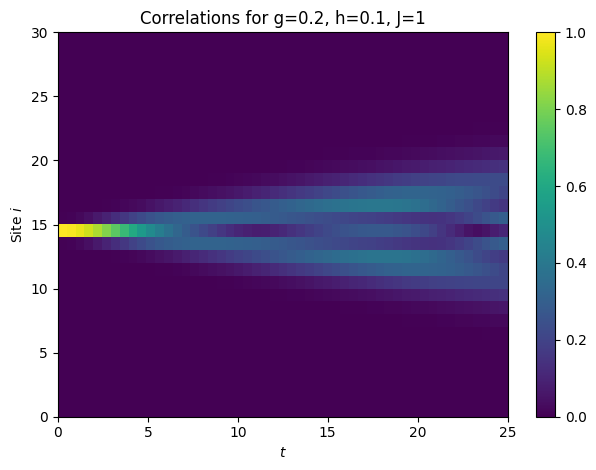

0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100


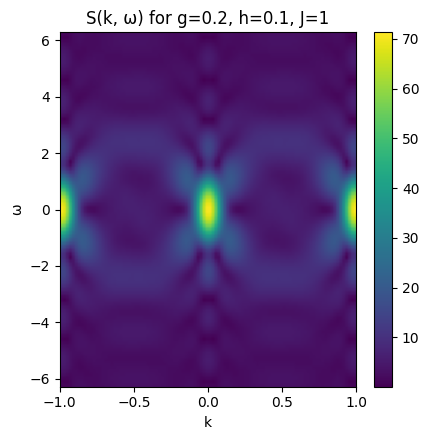

finite TEBD, (imaginary time evolution)
L=50, J=1.0, g=2.00
dt = 0.10000: E = -106.1748503654974
dt = 0.01000: E = -106.6182953507872
dt = 0.00100: E = -106.6617279124001
dt = 0.00010: E = -106.6660512726816
dt = 0.00001: E = -106.6664839604145
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 12, 8, 4, 2]
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System Size: 50, Total time: 50.0
Calculating Dynamical correlation functions...
System 

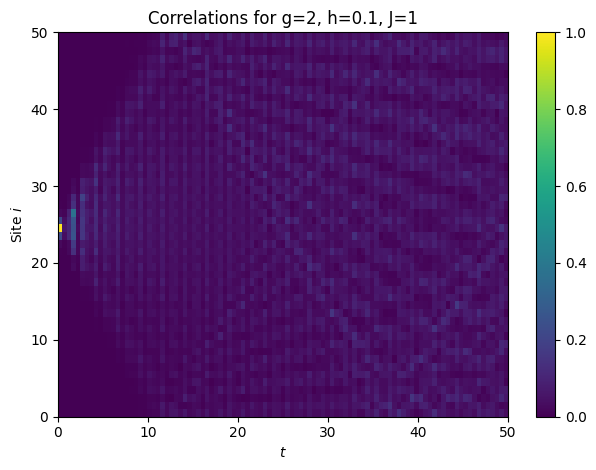

0 / 100
1 / 100
2 / 100
3 / 100
4 / 100
5 / 100
6 / 100
7 / 100
8 / 100
9 / 100
10 / 100
11 / 100
12 / 100
13 / 100
14 / 100
15 / 100
16 / 100
17 / 100
18 / 100
19 / 100
20 / 100
21 / 100
22 / 100
23 / 100
24 / 100
25 / 100
26 / 100
27 / 100
28 / 100
29 / 100
30 / 100
31 / 100
32 / 100
33 / 100
34 / 100
35 / 100
36 / 100
37 / 100
38 / 100
39 / 100
40 / 100
41 / 100
42 / 100
43 / 100
44 / 100
45 / 100
46 / 100
47 / 100
48 / 100
49 / 100
50 / 100
51 / 100
52 / 100
53 / 100
54 / 100
55 / 100
56 / 100
57 / 100
58 / 100
59 / 100
60 / 100
61 / 100
62 / 100
63 / 100
64 / 100
65 / 100
66 / 100
67 / 100
68 / 100
69 / 100
70 / 100
71 / 100
72 / 100
73 / 100
74 / 100
75 / 100
76 / 100
77 / 100
78 / 100
79 / 100
80 / 100
81 / 100
82 / 100
83 / 100
84 / 100
85 / 100
86 / 100
87 / 100
88 / 100
89 / 100
90 / 100
91 / 100
92 / 100
93 / 100
94 / 100
95 / 100
96 / 100
97 / 100
98 / 100
99 / 100


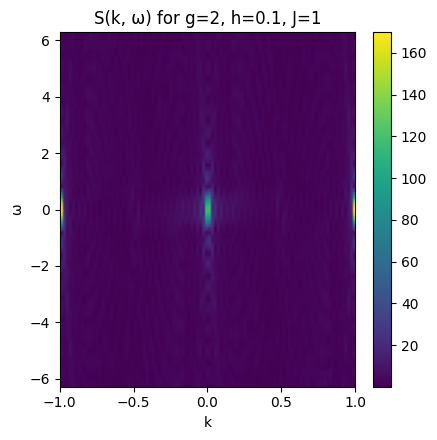

In [ ]:
L = 30
J = 1
h = 0.1
gs = [0.2, 2]

for g in gs:
    if g == 0.2:
        L = 30
        T = 25
    else:
        L = 50
        T = 50
    # Ground state
    E, psi0, model = TLFI_gs(L=L, J=J, g=g, h=h)

    # Correlations
    # T = N_steps * dt  
    correlations = []
    for i in range(psi0.L):
        c, _, _ = calc_correlations(model, psi0, sigma_y, sigma_y, i, L//2, dt=0.5, N_steps=int(T/0.5), chi_max=30, eps=1e-10)
        correlations.append(c)

    times = list(correlations[0].keys())
    values = [list(correlations[i].values()) for i in range(L)]

    # --- Correlation plot ---
    plt.figure(figsize=np.asarray((3.375, 3.375))*4/3)
    plt.xlabel(r"$t$")
    plt.ylabel(r'Site $i$')
    plt.imshow(np.abs(values), aspect="auto",
               extent=[times[0], times[-1], 0, L])
    plt.title(f"Correlations for g={g}, h={h}, J={J}")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"plots/corr_{g}_{h}_{J}.pdf")
    plt.show()

    # --- S(k, ω) ---
    def Gauss(t, sigma, N):
        return np.exp(-0.5 * t**2 / sigma**2 / N**2)

    def Fourier(values, k, omega, sigma):
        N = len(values[0])
        delta_t = times[1] - times[0]
        ret = 0j
        for i in range(len(values)):
            for m in range(N):
                ret += values[i][m] * np.exp(1j * (omega * times[m] - k * i)) \
                       * Gauss(times[m], sigma, N)
        return ret

    delta_t = times[1] - times[0]
    sigma = 0.5
    res = 100
    ks = np.linspace(-2*np.pi, 2*np.pi, res)
    omegas = np.linspace(-1/2/delta_t, 1/2/delta_t, res)

    S = np.zeros((res, res), dtype=complex)
    for i, k in enumerate(ks):
        for j, omega in enumerate(omegas):
            S[i, j] = Fourier(values, k, omega, sigma)
        print(i, "/", res)

    # --- Spectral plot ---
    plt.figure(figsize=np.asarray((3.375, 3.375))*4/3)
    plt.imshow(np.abs(S).T, extent=[omegas.min(), omegas.max(), ks.min(), ks.max()],
               aspect='auto', origin='lower')
    plt.title(f"S(k, ω) for g={g}, h={h}, J={J}")
    plt.ylabel("ω")
    plt.xlabel("k")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"plots/S_kw_{g}_{h}_{J}.pdf")
    plt.show()